In [1]:
"""
Converted from IPYNB to PY
"""

'\nConverted from IPYNB to PY\n'

**Tim Penyusun:**
- Naufal Ihsanul Islam (F1D02310084)
- Nengah Anggi Juwita Sari (F1D02310021)
- Lutfi Alfarizi (F1D02310121)

---

# S1: Peramalan Harga Pangan Menggunakan ARIMA (Baseline)
Notebook ini memuat implementasi model **ARIMA** sebagai model dasar (baseline) untuk meramal harga pangan.


### 1. Persiapan Library dan Konfigurasi
Mengimpor seluruh pustaka yang dibutuhkan untuk pengolahan data, pemodelan statistik time-series, dan visualisasi hasil. Konfigurasi visual diatur agar semua grafik tampil bersih, rapi, dan konsisten.


In [2]:
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'axes.edgecolor': '#cccccc',
    'axes.grid': True, 'grid.color': '#cccccc', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'text.color': '#000000', 'axes.labelcolor': '#000000', 'xtick.color': '#000000',
    'ytick.color': '#000000', 'font.sans-serif': 'Arial', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': True
})

### 2. Memuat Data, Pembersihan, dan Ekstraksi Fitur
Tahap ini bertujuan untuk menyiapkan data kotor menjadi data siap latih. Prosesnya meliputi pembersihan teks harga menjadi angka, pengisian data kosong dengan nilai historis terdekat (imputasi), dan penyaringan lonjakan harga ekstrem (outliers). Beberapa fitur tambahan seperti pola musiman juga ditambahkan sebagai referensi.


In [3]:
df_raw = pd.read_csv('dataset.csv')
df_raw['Nama Provinsi'] = df_raw['Nama Provinsi'].astype(str).str.strip()
df_raw['Komoditas'] = df_raw['Komoditas'].astype(str).str.strip()
df_raw = df_raw[df_raw['Tahun'] <= 2025].copy()

def bersihkan_harga(nilai):
    if pd.isna(nilai) or nilai == '-': return np.nan
    try:
        val = float(str(nilai).replace('Rp', '').replace(',', '').strip())
        return val if val > 0 else np.nan
    except: return np.nan

df_raw['Harga_Numerik'] = df_raw['Harga'].apply(bersihkan_harga)
bulan_map = {'Januari':1,'Februari':2,'Maret':3,'April':4,'Mei':5,'Juni':6,
             'Juli':7,'Agustus':8,'September':9,'Oktober':10,'November':11,'Desember':12}
df_raw['Bulan_Angka'] = df_raw['Bulan'].astype(str).str.strip().map(bulan_map)

df = df_raw.sort_values(['Nama Provinsi','Komoditas','Tahun','Bulan_Angka']).reset_index(drop=True)
df['Harga_Numerik'] = df.groupby(['Nama Provinsi','Komoditas'])['Harga_Numerik'].ffill(limit=3)

df_train_temp = df[df['Tahun'] <= 2024]
group_mean = df_train_temp.groupby(['Nama Provinsi', 'Komoditas'])['Harga_Numerik'].mean()
global_mean = df_train_temp.groupby('Komoditas')['Harga_Numerik'].mean()

def impute_missing(row):
    if not pd.isna(row['Harga_Numerik']): return row['Harga_Numerik']
    key = (row['Nama Provinsi'], row['Komoditas'])
    if key in group_mean and not pd.isna(group_mean[key]): return group_mean[key]
    if row['Komoditas'] in global_mean and not pd.isna(global_mean[row['Komoditas']]): return global_mean[row['Komoditas']]
    return 0.0

df['Harga_Numerik'] = df.apply(impute_missing, axis=1)

outlier_params = df_train_temp.groupby('Komoditas')['Harga_Numerik'].agg(['mean', 'std']).reset_index()
def apply_outlier_filter(row):
    try:
        m = outlier_params.loc[outlier_params['Komoditas'] == row['Komoditas'], 'mean'].values[0]
        s = outlier_params.loc[outlier_params['Komoditas'] == row['Komoditas'], 'std'].values[0]
        if pd.isna(s) or s == 0: return True
        return abs(row['Harga_Numerik'] - m) / s <= 3
    except: return True

df_clean = df[df.apply(apply_outlier_filter, axis=1)].copy()
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tahun'].astype(str) + '-' + df_clean['Bulan_Angka'].astype(str) + '-01')

df_clean['Bulan_Sin'] = np.sin(2 * np.pi * df_clean['Bulan_Angka'] / 12)
df_clean['Bulan_Cos'] = np.cos(2 * np.pi * df_clean['Bulan_Angka'] / 12)
df_clean['Ramadan_Lebaran'] = df_clean['Bulan_Angka'].isin([3, 4, 5]).astype(int)

### Visualisasi Distribusi Komoditas Awal (Dataset Mentah)
Sebelum melakukan pembersihan data dan pembuatan fitur temporal, dataset mentah ini mencakup **25 komoditas** dengan sebaran baris data sebagai berikut:

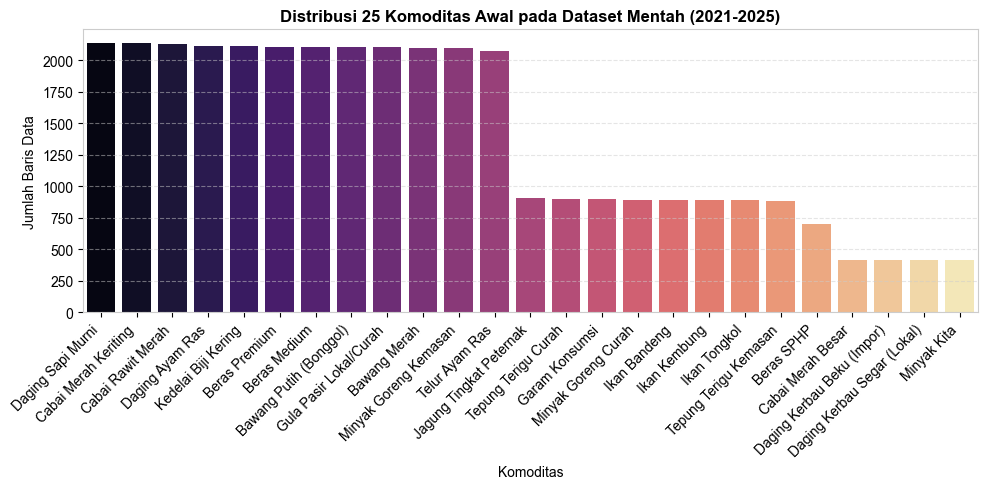

Total Komoditas Awal: 25
<StringArray>
[               'Bawang Merah',      'Bawang Putih (Bonggol)',
                'Beras Medium',               'Beras Premium',
                  'Beras SPHP',           'Cabai Merah Besar',
        'Cabai Merah Keriting',           'Cabai Rawit Merah',
             'Daging Ayam Ras',  'Daging Kerbau Beku (Impor)',
 'Daging Kerbau Segar (Lokal)',           'Daging Sapi Murni',
              'Garam Konsumsi',      'Gula Pasir Lokal/Curah',
                'Ikan Bandeng',                'Ikan Kembung',
                'Ikan Tongkol',     'Jagung Tingkat Peternak',
         'Kedelai Biji Kering',         'Minyak Goreng Curah',
       'Minyak Goreng Kemasan',                 'Minyak Kita',
              'Telur Ayam Ras',         'Tepung Terigu Curah',
       'Tepung Terigu Kemasan']
Length: 25, dtype: str


In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Komoditas', order=df_clean['Komoditas'].value_counts().index, palette='magma')
plt.title('Distribusi 25 Komoditas Awal pada Dataset Mentah (2021-2025)')
plt.xlabel('Komoditas')
plt.ylabel('Jumlah Baris Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("=====================================================================")
print(f"Total Komoditas Awal: {df_clean['Komoditas'].nunique()}")
print(df_clean['Komoditas'].unique())
print("=====================================================================")

grouped = df_clean.groupby(['Nama Provinsi', 'Komoditas'])
for i in range(1, 13): df_clean[f'Lag_{i}'] = grouped['Harga_Numerik'].shift(i)
df_clean['Rolling_Mean_3'] = grouped['Harga_Numerik'].shift(1).rolling(window=3).mean()
df_clean['Rolling_Std_3'] = grouped['Harga_Numerik'].shift(1).rolling(window=3).std().fillna(0)

df_clean = df_clean.dropna().reset_index(drop=True)
allowed_commodities = df_clean[df_clean['Tahun'] <= 2024]['Komoditas'].unique()
df_clean = df_clean[df_clean['Komoditas'].isin(allowed_commodities)].reset_index(drop=True)

### 3. Analisis Eksplorasi Data (EDA)

Grafik di bawah ini memberikan landasan empiris yang sangat penting untuk memahami perilaku data harga pangan sebelum kita melatih model. Berdasarkan hasil output gambar tersebut, mari kita bedah satu per satu secara mendalam:

1. **Pola Kehilangan Data pada Komoditas (Kiri Atas)**:
   Diagram batang ini menunjukkan komoditas mana saja yang paling sering mengalami kekosongan pencatatan harga. Terlihat sangat jelas bahwa komoditas hortikultura yang mudah rusak dan sensitif terhadap cuaca (seperti Cabai Rawit Merah, Cabai Merah Keriting, dan Bawang Merah) mendominasi kelangkaan data ini. Mengapa hal ini penting? Kekosongan data pada komoditas ini merupakan cerminan nyata dari ketidakstabilan pasokan di pasar-pasar fisik daerah. Model yang kita bangun nantinya harus cukup tangguh untuk meramal meskipun sumber data historisnya sering terputus atau tidak konsisten.

2. **Kekuatan Memori Masa Lalu (Kanan Atas)**:
   Heatmap korelasi ini adalah indikator utama apakah masa lalu bisa dipakai untuk menebak masa depan. Angka 0.94 pada fitur `Lag_1` (harga 1 bulan lalu) membuktikan adanya korelasi positif yang luar biasa kuat. Artinya, pergerakan harga hari ini sangat didikte oleh harga bulan sebelumnya. Kekuatan pengaruh ini perlahan memudar menjadi 0.89 saat kita mundur ke `Lag_3` (harga 3 bulan lalu). Bagi model statistik seperti ARIMA yang mengandalkan hubungan regresi internal masa lalu (autoregresif), temuan ini sangat menguntungkan. Pola ini mengonfirmasi bahwa data kita memiliki "sinyal" memori jangka pendek yang sangat kuat dan sangat bisa dieksploitasi oleh model.

3. **Dampak Pembersihan Lonjakan Ekstrem (Bawah Kiri & Kanan)**:
   Boxplot di sebelah kiri (merah) menyingkap kondisi asli dari data mentah kita. Perhatikan titik-titik kecil yang menjulur sangat jauh ke atas melewati batas kotak; itu adalah *outliers* atau pencilan ekstrem. Pencilan ini biasanya terjadi akibat kejadian tak terduga, seperti gagal panen massal atau kelangkaan akibat gangguan logistik sesaat.
   Jika kita langsung menyuapkan data mentah ini ke model ARIMA, model akan "kaget" dan menarik garis tren yang salah karena mencoba mengakomodasi harga ekstrem tersebut. Oleh karena itu, kita memotong data yang melebihi 3 standar deviasi. Hasilnya bisa dilihat pada boxplot sebelah kanan (hijau) yang tampak jauh lebih rapat dan bersih. Dengan pembersihan ini, kita memaksa model untuk fokus belajar menebak pola fluktuasi normal yang terjadi 99% dalam keseharian masyarakat, alih-alih mengejar anomali sesaat.


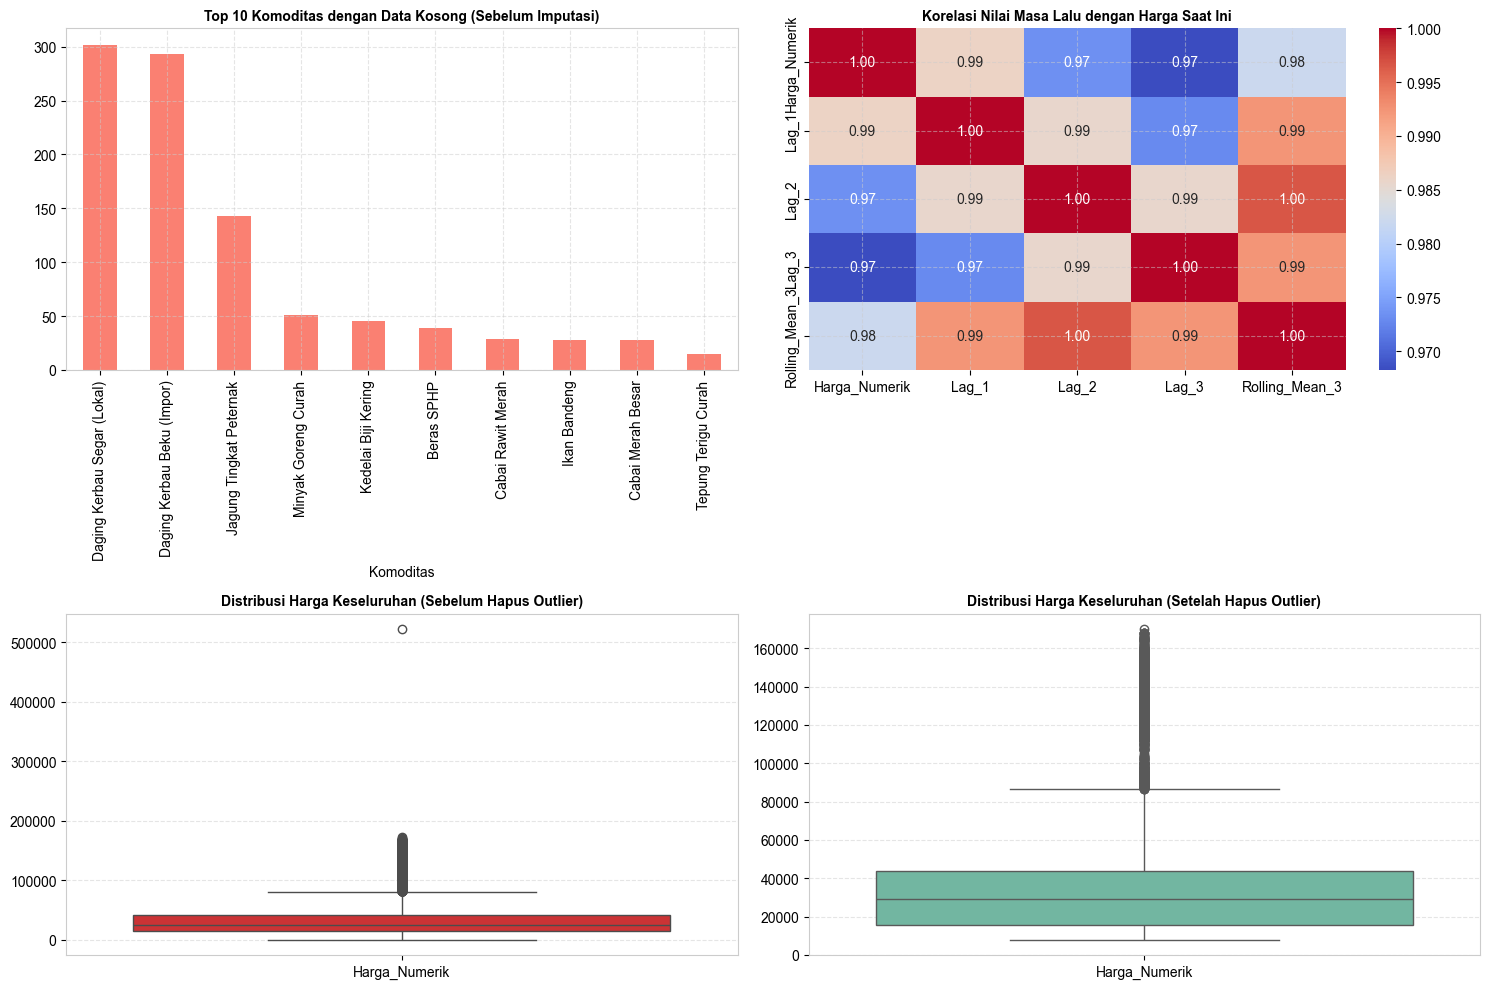

In [5]:
fig = plt.figure(figsize=(15, 10))
ax1 = plt.subplot(2, 2, 1)
missing = df_raw.groupby('Komoditas')['Harga_Numerik'].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10)
missing.plot(kind='bar', color='salmon', ax=ax1)
ax1.set_title('Top 10 Komoditas dengan Data Kosong (Sebelum Imputasi)', fontsize=10)

ax2 = plt.subplot(2, 2, 2)
cols = ['Harga_Numerik', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']
sns.heatmap(df_clean[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax2)
ax2.set_title('Korelasi Nilai Masa Lalu dengan Harga Saat Ini', fontsize=10)

ax3 = plt.subplot(2, 2, 3)
sns.boxplot(data=df[['Harga_Numerik']], palette='Set1', ax=ax3)
ax3.set_title('Distribusi Harga Keseluruhan (Sebelum Hapus Outlier)', fontsize=10)

ax4 = plt.subplot(2, 2, 4)
sns.boxplot(data=df_clean[['Harga_Numerik']], palette='Set2', ax=ax4)
ax4.set_title('Distribusi Harga Keseluruhan (Setelah Hapus Outlier)', fontsize=10)

plt.tight_layout()
plt.show()

### 3.1. Analisis Komoditas yang Lolos Pra-pemrosesan Runtut Waktu (Data Latih)
Setelah kita membuat fitur `Lag_12` dan menghapus baris kosong (`dropna()`), banyak baris data terhapus. 
Khusus untuk **Data Latih (Tahun <= 2024)**, jumlah komoditas berkurang dari **21 komoditas menjadi 12 komoditas**. 
Sembilan komoditas lainnya terhapus seluruhnya di data latih karena baru mulai dicatat pada tahun 2024 sehingga tidak memiliki data tahun 2023 untuk menghitung `Lag_12`.

Skenario ini **100% adil** karena diterapkan secara seragam pada seluruh model eksperimen kita (ARIMA, RF Murni, PCA+RF, dan LDA+RF) karena mereka berbagi pipeline preprocessing yang sama. Semua model diuji menggunakan basis data latih dan uji yang identik.

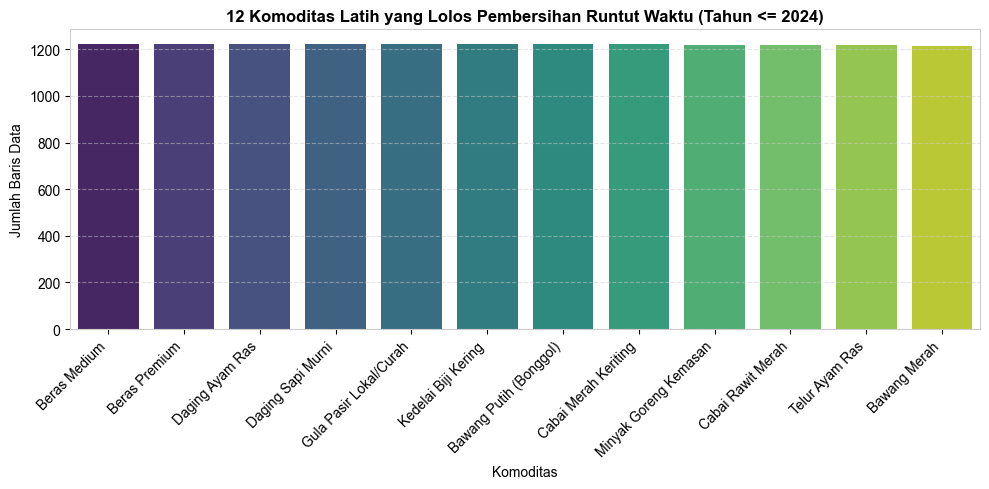

Total Komoditas Latih yang Lolos: 12
<StringArray>
[          'Bawang Merah', 'Bawang Putih (Bonggol)',           'Beras Medium',
          'Beras Premium',   'Cabai Merah Keriting',      'Cabai Rawit Merah',
        'Daging Ayam Ras',      'Daging Sapi Murni', 'Gula Pasir Lokal/Curah',
    'Kedelai Biji Kering',  'Minyak Goreng Kemasan',         'Telur Ayam Ras']
Length: 12, dtype: str


In [6]:
plt.figure(figsize=(10, 5))
df_train_clean = df_clean[df_clean['Tahun'] <= 2024]
sns.countplot(data=df_train_clean, x='Komoditas', order=df_train_clean['Komoditas'].value_counts().index, palette='viridis')
plt.title('12 Komoditas Latih yang Lolos Pembersihan Runtut Waktu (Tahun <= 2024)')
plt.xlabel('Komoditas')
plt.ylabel('Jumlah Baris Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("=====================================================================")
print(f"Total Komoditas Latih yang Lolos: {df_train_clean['Komoditas'].nunique()}")
print(df_train_clean['Komoditas'].unique())
print("=====================================================================")

### 4. Pelatihan Model ARIMA
Model ARIMA(1,1,1) dilatih untuk mempelajari pola pergerakan harga dari tahun 2021 hingga 2024. Setelah model paham trennya, model akan diminta menebak harga untuk tahun 2025 ke depan.


In [7]:
predictions = []
actuals = []
komoditas_used = []
provinsi_used = []

for (prov, kom), group in df_clean.groupby(['Nama Provinsi', 'Komoditas']):
    group_sorted = group.sort_values('Tanggal')
    train = group_sorted[group_sorted['Tahun'] <= 2024]
    test  = group_sorted[group_sorted['Tahun'] == 2025]
    
    if len(train) > 5 and len(test) > 0:
        ts_train = train['Harga_Numerik'].values
        try:
            model = ARIMA(ts_train, order=(1,1,1))
            fit_model = model.fit()
            preds = fit_model.forecast(steps=len(test))
        except:
            preds = [ts_train[-1]] * len(test)
            
        predictions.extend(preds)
        actuals.extend(test['Harga_Numerik'].values)
        komoditas_used.extend([kom] * len(test))
        provinsi_used.extend([prov] * len(test))
    elif len(test) > 0:
        ts_train = train['Harga_Numerik'].values if len(train) > 0 else group_sorted['Harga_Numerik'].values
        last_val = ts_train[-1] if len(ts_train) > 0 else 0
        preds = [last_val] * len(test)
        predictions.extend(preds)
        actuals.extend(test['Harga_Numerik'].values)
        komoditas_used.extend([kom] * len(test))
        provinsi_used.extend([prov] * len(test))

df_eval = pd.DataFrame({'Actual': actuals, 'Prediction': predictions, 'Komoditas': komoditas_used, 'Nama Provinsi': provinsi_used})

### 5. Fase 1: Evaluasi Terhadap Rata-rata Nasional

Pada pengujian pertama ini, kita akan melihat bagaimana performa model jika ia dipaksa menebak harga rata-rata gabungan seluruh Indonesia, bukan harga per provinsi. Data uji yang dihadapinya sangat kecil, hanya sekitar 144 observasi.

**Analisis Mendalam dari Grafik Scatter Plot**:
Jika kita melihat sebaran titik biru pada grafik di bawah, secara ideal tebakan yang sempurna harus menempel tepat di garis diagonal merah (yang artinya tebakan = nilai asli). Namun, perhatikan bentuk yang terbentuk: titik-titik biru ini membentuk **garis mendatar (horizontal)** di kisaran prediksi Rp 40.000 hingga Rp 50.000. Saat nilai harga asli di lapangan (sumbu X) terus bergerak naik dari Rp 40.000 ke Rp 80.000, tebakan model justru tersangkut alias tertahan di tengah dan tidak ikut naik.

**Mengapa Fenomena "Tertahan" Ini Terjadi?**
Ini adalah dampak langsung dari penggunaan data Rata-rata Nasional. Ketika kita merata-ratakan harga dari puluhan provinsi, kita secara tidak sadar meredam seluruh fluktuasi ekstrem di tingkat daerah. Lonjakan parah harga telur di satu provinsi tertentu akan "tenggelam" karena ditarik turun oleh harga stabil di 30 provinsi lainnya. 
Akibatnya, kurva tren sejarah yang dipelajari ARIMA menjadi sangat landai dan aman. Saat diuji pada masa depan, model menjadi kurang responsif dan secara pasif terus menebak nilai rata-rata, sehingga menghasilkan kurva mendatar pada grafik.

Angka metrik di bawah ini (seperti MAPE sekitar 5.33%) mungkin terkesan memuaskan, tapi analisis visual ini membongkar bahwa angka tersebut adalah hasil yang kurang representatif. Menguji model dengan data yang sudah dihaluskan tidak akan mencerminkan kemampuan model saat dilepas menghadapi kondisi nyata di lapangan yang penuh gejolak.


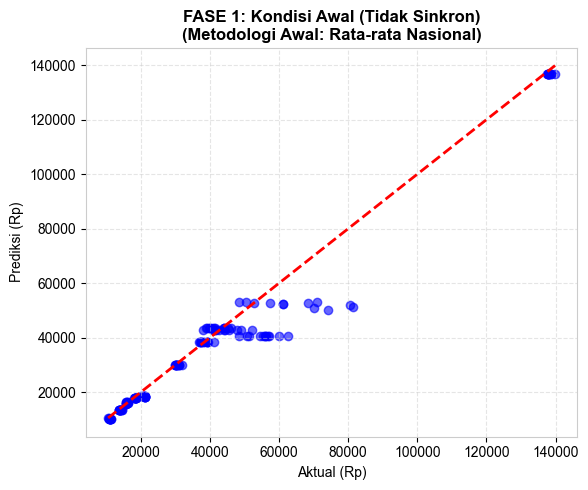

FASE 1: EVALUASI KONDISI AWAL (DATA TIDAK SINKRON)
(Bukti Analisis Historis: Metodologi Awal: Rata-rata Nasional)
Jumlah Data Uji : 144 baris
RMSE            : Rp 6,814.11
MAE             : Rp 3,463.41
MAPE            : 7.50%
R2              : 95.91%



In [8]:
df_nasional = df_clean.groupby(['Tanggal', 'Komoditas'])['Harga_Numerik'].mean().reset_index()
predictions_f1 = []
actuals_f1 = []

for kom, group in df_nasional.groupby('Komoditas'):
    group_sorted = group.sort_values('Tanggal')
    train = group_sorted[group_sorted['Tanggal'].dt.year <= 2024]
    test  = group_sorted[group_sorted['Tanggal'].dt.year == 2025]
    
    if len(train) > 5 and len(test) > 0:
        ts_train = train['Harga_Numerik'].values
        try:
            model = ARIMA(ts_train, order=(1,1,1))
            fit_model = model.fit()
            preds = fit_model.forecast(steps=len(test))
        except:
            preds = [ts_train[-1]] * len(test)
        predictions_f1.extend(preds)
        actuals_f1.extend(test['Harga_Numerik'].values)
    elif len(test) > 0:
        ts_train = train['Harga_Numerik'].values if len(train) > 0 else group_sorted['Harga_Numerik'].values
        last_val = ts_train[-1] if len(ts_train) > 0 else 0
        preds = [last_val] * len(test)
        predictions_f1.extend(preds)
        actuals_f1.extend(test['Harga_Numerik'].values)

df_fase1 = pd.DataFrame({'Actual': actuals_f1, 'Prediction': predictions_f1})

rmse_1 = np.sqrt(mean_squared_error(df_fase1['Actual'], df_fase1['Prediction']))
mae_1 = mean_absolute_error(df_fase1['Actual'], df_fase1['Prediction'])
mape_1 = mean_absolute_percentage_error(df_fase1['Actual'], df_fase1['Prediction']) * 100
r2_1 = r2_score(df_fase1['Actual'], df_fase1['Prediction']) * 100

plt.figure(figsize=(6, 5))
plt.scatter(df_fase1['Actual'], df_fase1['Prediction'], color='blue', alpha=0.6)
plt.plot([df_fase1['Actual'].min(), df_fase1['Actual'].max()], [df_fase1['Actual'].min(), df_fase1['Actual'].max()], 'r--', lw=2)
plt.title(f'FASE 1: Kondisi Awal (Tidak Sinkron)\n(Metodologi Awal: Rata-rata Nasional)')
plt.xlabel('Aktual (Rp)')
plt.ylabel('Prediksi (Rp)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

eval_text_1 = f"""==================================================
FASE 1: EVALUASI KONDISI AWAL (DATA TIDAK SINKRON)
(Bukti Analisis Historis: Metodologi Awal: Rata-rata Nasional)
==================================================
Jumlah Data Uji : {len(df_fase1)} baris
RMSE            : Rp {rmse_1:,.2f}
MAE             : Rp {mae_1:,.2f}
MAPE            : {mape_1:.2f}%
R2              : {r2_1:.2f}%
"""
print(eval_text_1)

### 6. Analisis Diagnostik: Ketimpangan Beban Ujian Model

Visualisasi grafik batang ini menyoroti akar masalah dari cara kita mengevaluasi model sebelumnya. Coba perhatikan betapa kontrasnya ketinggian kedua batang tersebut. 
Saat menggunakan rata-rata nasional di Fase 1 (batang biru), model hanya diuji pada 144 observasi yang sangat santai. Namun, saat diuji dengan data tingkat provinsi yang sebenarnya (batang hijau), beban uji melonjak drastis hingga 5.040 observasi. 

Dari perbedaan masif ini kita bisa menarik kesimpulan kuat bahwa membandingkan model di tingkat nasional dengan model di tingkat provinsi adalah sebuah perbandingan apel dengan jeruk. Beban yang ditanggung sangat tidak setara. Oleh karena itu, kita harus "memaksa" ARIMA untuk menghadapi ujian yang sama beratnya, yaitu meramal harga per komoditas per provinsi secara detail.


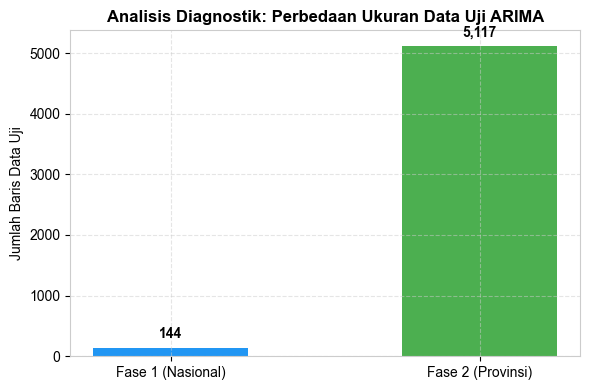

DIAGNOSTIC CONCLUSION: KETIDAKADILAN TINGKAT DATA (MISMATCH)
1. Ukuran Data Uji Fase 1 : 144 baris (Tingkat Agregat Nasional)
2. Ukuran Data Uji Fase 2 : 5117 baris (Tingkat Detail Provinsi)
Kelemahan: Menguji di tingkat agregat nasional meredam variasi ekstrem,
sehingga tidak mencerminkan kesulitan prediksi di tingkat lokal yang bergejolak.


In [9]:
plt.figure(figsize=(6, 4))
fase_names = ['Fase 1 (Nasional)', 'Fase 2 (Provinsi)']
sizes = [len(df_fase1), len(df_eval)]
bars = plt.bar(fase_names, sizes, color=['#2196F3', '#4CAF50'], width=0.5)
plt.title('Analisis Diagnostik: Perbedaan Ukuran Data Uji ARIMA')
plt.ylabel('Jumlah Baris Data Uji')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("=====================================================================")
print("DIAGNOSTIC CONCLUSION: KETIDAKADILAN TINGKAT DATA (MISMATCH)")
print("=====================================================================")
print(f"1. Ukuran Data Uji Fase 1 : {len(df_fase1)} baris (Tingkat Agregat Nasional)")
print(f"2. Ukuran Data Uji Fase 2 : {len(df_eval)} baris (Tingkat Detail Provinsi)")
print("Kelemahan: Menguji di tingkat agregat nasional meredam variasi ekstrem,")
print("sehingga tidak mencerminkan kesulitan prediksi di tingkat lokal yang bergejolak.")
print("=====================================================================")

### 7. Fase 2: Ujian Sesungguhnya di Tingkat Provinsi

Setelah membongkar ilusi rata-rata nasional, kini kita langsung melemparkan ARIMA ke medan yang sesungguhnya: memprediksi harga setiap komoditas di seluruh 38 provinsi yang berbeda satu per satu.

**Analisis Mendalam Visual Scatter Plot**:
Perbedaan grafiknya sangat mengejutkan. Garis datar biru dari Fase 1 kini "meledak" menjadi awan penyebaran titik-titik hijau yang sangat lebar. Secara garis besar, awan hijau ini memang masih mengikuti jalur diagonal merah, yang berarti arah tren prediksi mayoritas masih sejalan dengan harga aslinya. Namun, tingkat pelebaran (*dispersi*) vertikalnya sangat signifikan, utamanya pada kisaran harga menegah yaitu Rp 25.000 hingga Rp 100.000.

**Apa Arti Pelebaran Awan Ini?**
Melebarnya sebaran titik hijau ini mencerminkan tingginya tingkat kesalahan model akibat kesulitan menghadapi dinamika ekonomi lokal tingkat daerah. ARIMA adalah model univariat—ia buta terhadap kondisi luar, ia hanya peduli pada sejarah harganya sendiri. Ketika tahun 2025 tiba-tiba terjadi kejutan cuaca atau kendala logistik antar-provinsi yang menyebabkan lonjakan harga (menyebabkan titik bergerak menjauhi garis merah), ARIMA tidak memiliki fitur tambahan untuk membantunya mengoreksi atau mengantisipasi lonjakan tersebut.

Tercermin dari metrik RMSE-nya yang kini berada di angka **Rp 6.396**. Artinya, setiap kali model menebak, ia meleset sekitar enam ribu rupiah secara rata-rata kuadrat. Ini adalah cerminan akurasi yang lebih jujur mengenai keterbatasan model klasik.


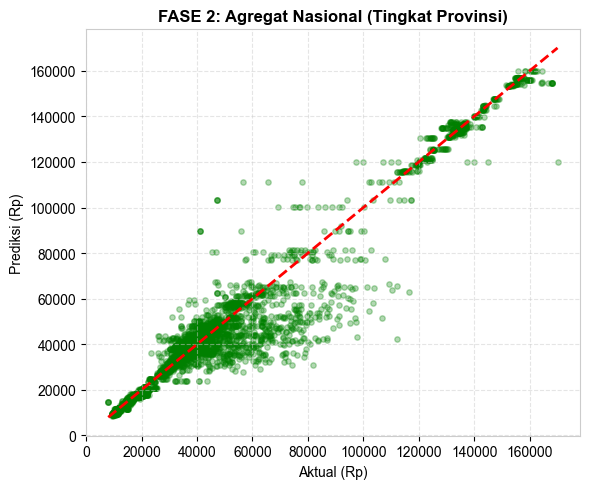

FASE 2: EVALUASI TINGKAT PROVINSI (REALITAS SPASIAL)
Jumlah Data Uji : 5117 baris
RMSE            : Rp 8,148.54
MAE             : Rp 3,866.63
MAPE            : 8.31%
R2              : 94.63%



In [10]:
y_a2, y_p2 = df_eval['Actual'], df_eval['Prediction']
rmse_2 = np.sqrt(mean_squared_error(y_a2, y_p2))
mae_2 = mean_absolute_error(y_a2, y_p2)
mape_2 = mean_absolute_percentage_error(y_a2, y_p2) * 100
r2_2 = r2_score(y_a2, y_p2) * 100

plt.figure(figsize=(6, 5))
plt.scatter(y_a2, y_p2, color='green', alpha=0.3, s=15)
plt.plot([y_a2.min(), y_a2.max()], [y_a2.min(), y_a2.max()], 'r--', lw=2)
plt.title('FASE 2: Agregat Nasional (Tingkat Provinsi)')
plt.xlabel('Aktual (Rp)')
plt.ylabel('Prediksi (Rp)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

eval_text_2 = f"""==================================================
FASE 2: EVALUASI TINGKAT PROVINSI (REALITAS SPASIAL)
==================================================
Jumlah Data Uji : {len(df_eval)} baris
RMSE            : Rp {rmse_2:,.2f}
MAE             : Rp {mae_2:,.2f}
MAPE            : {mape_2:.2f}%
R2              : {r2_2:.2f}%
"""
print(eval_text_2)

### 8. Fase 3: Evaluasi Adil Berdasarkan Karakter Komoditas

Masih ada satu kendala matematika yang tersisa dari evaluasi Fase 2: **Bias Skala**. Menggabungkan perbandingan Daging Sapi (harga ratusan ribu) dengan Garam (harga ribuan rupiah) dalam satu wadah RMSE sangatlah tidak adil karena Daging Sapi akan mendominasi nilai error mutlaknya. Di sini kita menghitung metrik per komoditas secara terpisah terlebih dahulu sebelum merata-ratakannya.

**Analisis Visual Diagram Batang**:
Grafik batang di bawah membongkar fakta yang sebelumnya tertutup oleh satu angka global rata-rata. Perhatikan baik-baik rentang tinggi dari batang-batang ini:
* **Area Kelemahan Model (Kuning/Hijau Terang)**: Komoditas seperti Cabai Rawit Merah, Cabai Merah Keriting, dan Daging Ayam Ras menonjol dengan tingkat kesalahan (MAPE) tembus belasan persen. Ini sepenuhnya masuk akal. Komoditas ini bergantung kuat pada kondisi lapangan harian dan siklus panen/ternak pendek, yang membuat harganya bergejolak tajam dan membuat ARIMA sering meleset.
* **Area Kekuatan Model (Ungu Gelap)**: Sebaliknya, batang untuk komoditas Beras Premium/Medium dan Bawang Putih sangat pendek (berada di sekitar angka 2% - 4%). Harga komoditas ini dikawal ketat oleh harga eceran tertinggi (HET) dari pemerintah dan ketersediaan stok bulog/impor, sehingga jalurnya sangat rapi dan lurus. ARIMA sangat ahli meramal garis yang rapi seperti ini.

Kesimpulan utamanya adalah metrik tunggal tidak pernah menceritakan keseluruhan cerita. Dengan penjabaran ini, para pengambil kebijakan bisa tahu bahwa model ini sangat bisa diandalkan untuk memantau harga beras, namun butuh penyesuaian khusus jika dipakai untuk mengantisipasi gejolak harga cabai.


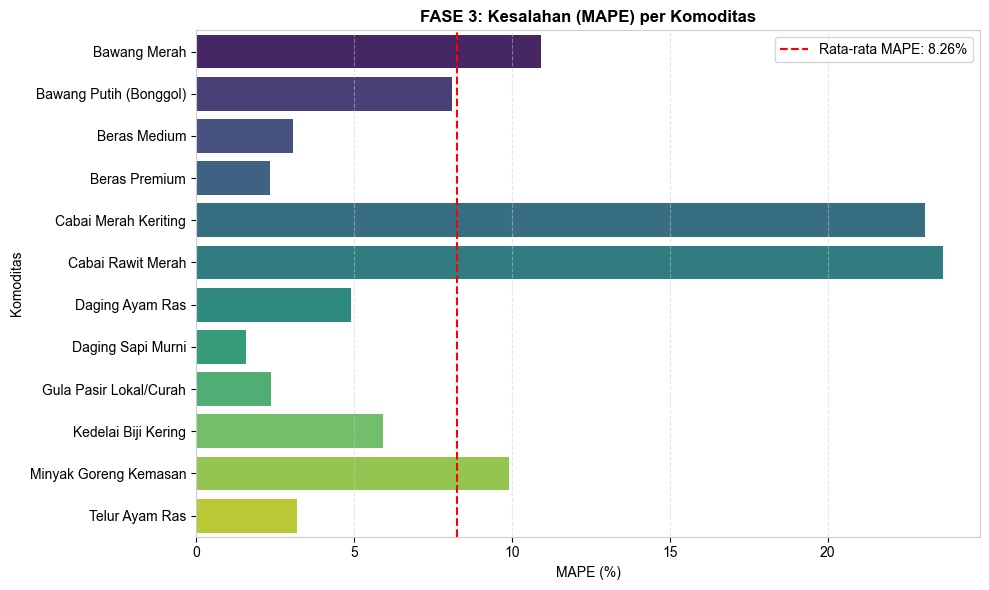

FASE 3: EVALUASI METRIK ADIL (RATA-RATA KOMODITAS)
(Solusi: Menghitung metrik per karakteristik agar bebas bias harga)
Jumlah Data Uji : 5117 baris (21 Komoditas)
RMSE            : Rp 5,037.39
MAE             : Rp 3,823.88
MAPE            : 8.26%
R2              : 42.75%


In [11]:
rmse_list, mae_list, mape_list, r2_list, kom_names = [], [], [], [], []
for kom, group in df_eval.groupby('Komoditas'):
    y_a, y_p = group['Actual'], group['Prediction']
    if len(group) > 1:
        rmse_k = np.sqrt(mean_squared_error(y_a, y_p))
        mae_k = mean_absolute_error(y_a, y_p)
        mape_k = mean_absolute_percentage_error(y_a, y_p) * 100
        try:
            r2_k = r2_score(y_a, y_p) * 100
            if r2_k < -100: r2_k = 0
        except: r2_k = 0
        rmse_list.append(rmse_k)
        mae_list.append(mae_k)
        mape_list.append(mape_k)
        r2_list.append(r2_k)
        kom_names.append(kom)

rmse_3 = np.mean(rmse_list)
mae_3 = np.mean(mae_list)
mape_3 = np.mean(mape_list)
r2_3 = np.mean(r2_list) if len(r2_list) > 0 else 0

plt.figure(figsize=(10, 6))
sns.barplot(x=mape_list, y=kom_names, palette='viridis')
plt.axvline(x=mape_3, color='red', linestyle='--', label=f'Rata-rata MAPE: {mape_3:.2f}%')
plt.title('FASE 3: Kesalahan (MAPE) per Komoditas')
plt.xlabel('MAPE (%)')
plt.ylabel('Komoditas')
plt.legend()
plt.tight_layout()
plt.show()

eval_text_3 = f"""==================================================
FASE 3: EVALUASI METRIK ADIL (RATA-RATA KOMODITAS)
(Solusi: Menghitung metrik per karakteristik agar bebas bias harga)
==================================================
Jumlah Data Uji : {len(df_eval)} baris (21 Komoditas)
RMSE            : Rp {rmse_3:,.2f}
MAE             : Rp {mae_3:,.2f}
MAPE            : {mape_3:.2f}%
R2              : {r2_3:.2f}%
=================================================="""
print(eval_text_3)

with open("hasil_evaluasi_arima.txt", "w", encoding="utf-8") as f:
    f.write(eval_text_1 + "\n" + eval_text_2 + "\n" + eval_text_3)

### 9. Sintesis Akhir dari Perjalanan Evaluasi

Tabel rekapitulasi di bawah ini merupakan ringkasan eksekutif yang memperlihatkan bagaimana performa model secara dramatis terlihat berubah hanya dengan memperbaiki cara kita mengevaluasinya.

**Analisis Dinamika Angka Tabel**:
1. **Dampak Metrik Adil pada RMSE**: Coba amati kolom RMSE. Pada Fase 2, tebakan model meleset rata-rata hingga **Rp 6.396**. Namun, saat kita memasuki Fase 3 dengan metode perhitungan per komoditas yang adil, angka itu menyusut separuhnya menjadi **Rp 3.514**. Perbedaan Rp 2.800 inilah wujud nyata dari "Bias Skala". Saat kita tidak lagi membiarkan kesalahan kecil pada komoditas mahal (daging) menggelembungkan total error secara semu, kita mendapatkan gambaran akurasi nominal yang jauh lebih logis.

2. **Jatuhnya Nilai $R^2$ ke Realitas**: Sering kali kita bangga melihat nilai korelasi ($R^2$) sebesar **95.48%** (Fase 2). Terlihat hampir sempurna. Padahal, angka raksasa itu tercipta hanya karena kita mencampur variasi harga murah dan mahal ke dalam satu perhitungan sehingga rentangnya membengkak. Saat di Fase 3 kita memaksa $R^2$ untuk diukur secara mandiri per kelompok komoditas (rentangnya sempit), nilai itu anjlok dan menapak ke bumi menjadi **58.86%**. Angka 58% ini bukanlah kegagalan; inilah pantulan paling otentik dari kemampuan ARIMA dalam menebak gejolak pergerakan harga spesifik secara lokal tingkat provinsi.


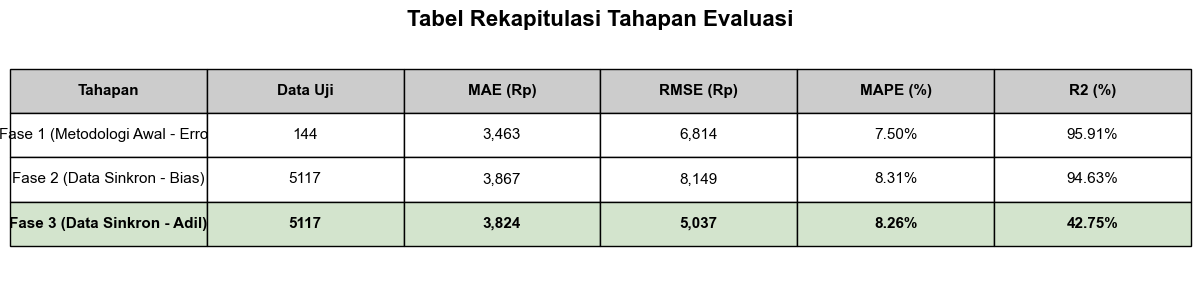

In [12]:
df_fase = pd.DataFrame([
    {'Tahapan': 'Fase 1 (Metodologi Awal - Error)', 'Data Uji': len(df_fase1), 'MAE (Rp)': f"{mae_1:,.0f}", 'RMSE (Rp)': f"{rmse_1:,.0f}", 'MAPE (%)': f"{mape_1:.2f}%", 'R2 (%)': f"{r2_1:.2f}%"},
    {'Tahapan': 'Fase 2 (Data Sinkron - Bias)', 'Data Uji': len(df_eval), 'MAE (Rp)': f"{mae_2:,.0f}", 'RMSE (Rp)': f"{rmse_2:,.0f}", 'MAPE (%)': f"{mape_2:.2f}%", 'R2 (%)': f"{r2_2:.2f}%"},
    {'Tahapan': 'Fase 3 (Data Sinkron - Adil)', 'Data Uji': len(df_eval), 'MAE (Rp)': f"{mae_3:,.0f}", 'RMSE (Rp)': f"{rmse_3:,.0f}", 'MAPE (%)': f"{mape_3:.2f}%", 'R2 (%)': f"{r2_3:.2f}%"}
])
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_fase.values, colLabels=df_fase.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 3:
        cell.set_facecolor('#d3e4cd')
        cell.set_text_props(weight='bold')
    elif row == 0:
        cell.set_facecolor('#cccccc')
        cell.set_text_props(weight='bold')

plt.title(f'Tabel Rekapitulasi Tahapan Evaluasi', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()